The following additional libraries are needed to run this
notebook. Note that running on Colab is experimental, please report a Github
issue if you have any problem.

# Bahdanau 注意力
:label:`sec_seq2seq_attention`

 :numref:`sec_seq2seq`中探讨了机器翻译问题：
通过设计一个基于两个循环神经网络的编码器-解码器架构，
用于序列到序列学习。
具体来说，循环神经网络编码器将长度可变的序列转换为固定形状的上下文变量，
然后循环神经网络解码器根据生成的词元和上下文变量
按词元生成输出（目标）序列词元。
然而，即使并非所有输入（源）词元都对解码某个词元都有用，
在每个解码步骤中仍使用编码*相同*的上下文变量。
有什么方法能改变上下文变量呢？

我们试着从 :cite:`Graves.2013`中找到灵感：
在为给定文本序列生成手写的挑战中，
Graves设计了一种可微注意力模型，
将文本字符与更长的笔迹对齐，
其中对齐方式仅向一个方向移动。
受学习对齐想法的启发，Bahdanau等人提出了一个没有严格单向对齐限制的
可微注意力模型 :cite:`Bahdanau.Cho.Bengio.2014`。
在预测词元时，如果不是所有输入词元都相关，模型将仅对齐（或参与）输入序列中与当前预测相关的部分。这是通过将上下文变量视为注意力集中的输出来实现的。

## 模型

下面描述的Bahdanau注意力模型
将遵循 :numref:`sec_seq2seq`中的相同符号表达。
这个新的基于注意力的模型与 :numref:`sec_seq2seq`中的模型相同，
只不过 :eqref:`eq_seq2seq_s_t`中的上下文变量$\mathbf{c}$
在任何解码时间步$t'$都会被$\mathbf{c}_{t'}$替换。
假设输入序列中有$T$个词元，
解码时间步$t'$的上下文变量是注意力集中的输出：

$$\mathbf{c}_{t'} = \sum_{t=1}^T \alpha(\mathbf{s}_{t' - 1}, \mathbf{h}_t) \mathbf{h}_t,$$

其中，时间步$t' - 1$时的解码器隐状态$\mathbf{s}_{t' - 1}$是查询，
编码器隐状态$\mathbf{h}_t$既是键，也是值，
注意力权重$\alpha$是使用 :eqref:`eq_attn-scoring-alpha`
所定义的加性注意力打分函数计算的。

与 :numref:`fig_seq2seq_details`中的循环神经网络编码器-解码器架构略有不同，
 :numref:`fig_s2s_attention_details`描述了Bahdanau注意力的架构。

![一个带有Bahdanau注意力的循环神经网络编码器-解码器模型](https://github.com/d2l-ai/d2l-zh-pytorch-colab/blob/master/img/seq2seq-attention-details.svg?raw=1)
:label:`fig_s2s_attention_details`


In [1]:
import torch
from torch import nn

## 定义注意力解码器

下面看看如何定义Bahdanau注意力，实现循环神经网络编码器-解码器。
其实，我们只需重新定义解码器即可。
为了更方便地显示学习的注意力权重，
以下`AttentionDecoder`类定义了[**带有注意力机制解码器的基本接口**]。


In [3]:
class AttentionDecoder(nn.Module):
    """带有注意力机制解码器的基本接口"""
    def __init__(self, **kwargs):
        super().__init__()

    @property
    def attention_weights(self):
        raise NotImplementedError

接下来，让我们在接下来的`Seq2SeqAttentionDecoder`类中
[**实现带有Bahdanau注意力的循环神经网络解码器**]。
首先，初始化解码器的状态，需要下面的输入：

1. 编码器在所有时间步的最终层隐状态，将作为注意力的键和值；
1. 上一时间步的编码器全层隐状态，将作为初始化解码器的隐状态；
1. 编码器有效长度（排除在注意力池中填充词元）。

在每个解码时间步骤中，解码器上一个时间步的最终层隐状态将用作查询。
因此，注意力输出和输入嵌入都连结为循环神经网络解码器的输入。


In [7]:
import torch
from torch import nn
from torch.nn import functional as F


def sequence_mask(X, valid_len, value=0):
    """在序列中遮蔽无效位置"""
    maxlen = X.size(1)

    mask = torch.arange(
        maxlen,
        dtype=torch.float32,
        device=X.device
    )[None, :] < valid_len[:, None]

    X = X.clone()
    X[~mask] = value
    return X


def masked_softmax(X, valid_lens):
    """对最后一个维度做 softmax，并遮蔽无效位置"""
    if valid_lens is None:
        return F.softmax(X, dim=-1)

    shape = X.shape

    if valid_lens.dim() == 1:
        # valid_lens shape: (batch_size,)
        # repeat_interleave 后 shape: (batch_size * num_queries,)
        valid_lens = torch.repeat_interleave(valid_lens, shape[1])
    else:
        # valid_lens shape: (batch_size, num_queries)
        valid_lens = valid_lens.reshape(-1)

    # X shape: (batch_size, num_queries, num_kv)
    # reshape 后 shape: (batch_size * num_queries, num_kv)
    X = X.reshape(-1, shape[-1])

    # 无效位置设成很小的值，softmax 后接近 0
    X = sequence_mask(X, valid_lens, value=-1e6)

    return F.softmax(X.reshape(shape), dim=-1)


class AdditiveAttention(nn.Module):
    """加性注意力，不依赖 d2l"""
    def __init__(self, key_size, query_size, num_hiddens, dropout):
        super().__init__()

        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        # queries shape: (batch_size, num_queries, query_size)
        # keys shape:    (batch_size, num_kv, key_size)
        # values shape:  (batch_size, num_kv, value_size)

        queries = self.W_q(queries)
        keys = self.W_k(keys)

        # queries shape: (batch_size, num_queries, 1, num_hiddens)
        # keys shape:    (batch_size, 1, num_kv, num_hiddens)
        features = queries.unsqueeze(2) + keys.unsqueeze(1)

        features = torch.tanh(features)

        # scores shape: (batch_size, num_queries, num_kv)
        scores = self.w_v(features).squeeze(-1)

        self.attention_weights = masked_softmax(scores, valid_lens)

        # output shape: (batch_size, num_queries, value_size)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [8]:
class Seq2SeqEncoder(nn.Module):
    """用于序列到序列学习的循环神经网络编码器"""
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_size)

        self.rnn = nn.GRU(
            input_size=embed_size,
            hidden_size=num_hiddens,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0
        )

    def forward(self, X, *args):
        # X shape: (batch_size, num_steps)

        X = self.embedding(X)
        # X shape: (batch_size, num_steps, embed_size)

        X = X.permute(1, 0, 2)
        # X shape: (num_steps, batch_size, embed_size)

        output, state = self.rnn(X)
        # output shape: (num_steps, batch_size, num_hiddens)
        # state shape: (num_layers, batch_size, num_hiddens)

        return output, state

In [9]:
class Seq2SeqAttentionDecoder(AttentionDecoder):
    """带 Bahdanau 注意力的 Seq2Seq 解码器，不依赖 d2l"""

    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers,
                 dropout=0, **kwargs):
        super().__init__(**kwargs)

        self.attention = AdditiveAttention(
            key_size=num_hiddens,
            query_size=num_hiddens,
            num_hiddens=num_hiddens,
            dropout=dropout
        )

        self.embedding = nn.Embedding(vocab_size, embed_size)

        self.rnn = nn.GRU(
            input_size=embed_size + num_hiddens,
            hidden_size=num_hiddens,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        # enc_outputs = (outputs, hidden_state)
        # outputs shape:      (num_steps, batch_size, num_hiddens)
        # hidden_state shape: (num_layers, batch_size, num_hiddens)

        outputs, hidden_state = enc_outputs

        # attention 需要 batch-first:
        # enc_outputs shape: (batch_size, num_steps, num_hiddens)
        return outputs.permute(1, 0, 2), hidden_state, enc_valid_lens

    def forward(self, X, state):
        # X shape: (batch_size, num_steps)
        # enc_outputs shape: (batch_size, src_num_steps, num_hiddens)
        # hidden_state shape: (num_layers, batch_size, num_hiddens)

        enc_outputs, hidden_state, enc_valid_lens = state

        # X shape: (num_steps, batch_size, embed_size)
        X = self.embedding(X).permute(1, 0, 2)

        outputs = []
        self._attention_weights = []

        for x in X:
            # x shape: (batch_size, embed_size)

            # query shape: (batch_size, 1, num_hiddens)
            query = hidden_state[-1].unsqueeze(1)

            # context shape: (batch_size, 1, num_hiddens)
            context = self.attention(
                queries=query,
                keys=enc_outputs,
                values=enc_outputs,
                valid_lens=enc_valid_lens
            )

            # x shape after unsqueeze: (batch_size, 1, embed_size)
            x = x.unsqueeze(1)

            # x_and_context shape: (batch_size, 1, embed_size + num_hiddens)
            x_and_context = torch.cat((context, x), dim=-1)

            # GRU expects: (num_steps=1, batch_size, embed_size + num_hiddens)
            out, hidden_state = self.rnn(
                x_and_context.permute(1, 0, 2),
                hidden_state
            )

            # out shape: (1, batch_size, num_hiddens)
            outputs.append(out)

            self._attention_weights.append(self.attention.attention_weights)

        # outputs shape: (num_steps, batch_size, num_hiddens)
        outputs = torch.cat(outputs, dim=0)

        # outputs shape: (num_steps, batch_size, vocab_size)
        outputs = self.dense(outputs)

        # return shape: (batch_size, num_steps, vocab_size)
        return outputs.permute(1, 0, 2), [
            enc_outputs,
            hidden_state,
            enc_valid_lens
        ]

    @property
    def attention_weights(self):
        return self._attention_weights

接下来，使用包含7个时间步的4个序列输入的小批量[**测试Bahdanau注意力解码器**]。


In [10]:
encoder = Seq2SeqEncoder(vocab_size=10, embed_size=8, num_hiddens=16,
                             num_layers=2)
encoder.eval()
decoder = Seq2SeqAttentionDecoder(vocab_size=10, embed_size=8, num_hiddens=16,
                                  num_layers=2)
decoder.eval()
X = torch.zeros((4, 7), dtype=torch.long)  # (batch_size,num_steps)
state = decoder.init_state(encoder(X), None)
output, state = decoder(X, state)
output.shape, len(state), state[0].shape, len(state[1]), state[1][0].shape

(torch.Size([4, 7, 10]), 3, torch.Size([4, 7, 16]), 2, torch.Size([4, 16]))

## [**训练**]

与 :numref:`sec_seq2seq_training`类似，
我们在这里指定超参数，实例化一个带有Bahdanau注意力的编码器和解码器，
并对这个模型进行机器翻译训练。
由于新增的注意力机制，训练要比没有注意力机制的
 :numref:`sec_seq2seq_training`慢得多。


In [11]:
import os
import re
import collections
import requests
import zipfile
import torch
from torch.utils.data import DataLoader, TensorDataset


class Vocab:
    """简单词表"""
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []

        counter = collections.Counter([token for line in tokens for token in line])
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)

        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

        for token, freq in self.token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.token_to_idx['<unk>'])
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]


def download_extract_nmt():
    """下载并解压 D2L 使用的英法翻译数据集"""
    url = "http://d2l-data.s3-accelerate.amazonaws.com/fra-eng.zip"
    data_dir = "./data"
    zip_path = os.path.join(data_dir, "fra-eng.zip")
    extract_dir = os.path.join(data_dir, "fra-eng")

    os.makedirs(data_dir, exist_ok=True)

    if not os.path.exists(zip_path):
        print("Downloading dataset...")
        response = requests.get(url)
        response.raise_for_status()
        with open(zip_path, "wb") as f:
            f.write(response.content)

    if not os.path.exists(extract_dir):
        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(data_dir)

    return extract_dir


def read_data_nmt():
    """读取英法翻译数据"""
    data_dir = download_extract_nmt()
    file_path = os.path.join(data_dir, "fra.txt")

    with open(file_path, "r", encoding="utf-8") as f:
        return f.read()


def preprocess_nmt(text):
    """预处理文本"""
    def no_space(char, prev_char):
        return char in set(',.!?') and prev_char != ' '

    text = text.replace('\u202f', ' ').replace('\xa0', ' ').lower()

    out = []
    for i, char in enumerate(text):
        if i > 0 and no_space(char, text[i - 1]):
            out.append(' ')
        out.append(char)

    return ''.join(out)


def tokenize_nmt(text, num_examples=None):
    """分词"""
    source, target = [], []

    for i, line in enumerate(text.split('\n')):
        if num_examples and i > num_examples:
            break

        parts = line.split('\t')
        if len(parts) >= 2:
            source.append(parts[0].split(' '))
            target.append(parts[1].split(' '))

    return source, target


def truncate_pad(line, num_steps, padding_token):
    """截断或填充序列"""
    if len(line) > num_steps:
        return line[:num_steps]

    return line + [padding_token] * (num_steps - len(line))


def build_array_nmt(lines, vocab, num_steps):
    """把 token 序列转换成小批量张量"""
    lines = [vocab[line] for line in lines]

    # 每个目标序列后面加 <eos>
    lines = [line + [vocab['<eos>']] for line in lines]

    array = torch.tensor([
        truncate_pad(line, num_steps, vocab['<pad>'])
        for line in lines
    ])

    valid_len = (array != vocab['<pad>']).type(torch.int32).sum(dim=1)

    return array, valid_len


def load_data_nmt(batch_size, num_steps, num_examples=600):
    """返回 DataLoader 和源语言/目标语言词表"""
    text = preprocess_nmt(read_data_nmt())
    source, target = tokenize_nmt(text, num_examples)

    src_vocab = Vocab(
        source,
        min_freq=2,
        reserved_tokens=['<pad>', '<bos>', '<eos>']
    )

    tgt_vocab = Vocab(
        target,
        min_freq=2,
        reserved_tokens=['<pad>', '<bos>', '<eos>']
    )

    src_array, src_valid_len = build_array_nmt(source, src_vocab, num_steps)
    tgt_array, tgt_valid_len = build_array_nmt(target, tgt_vocab, num_steps)

    dataset = TensorDataset(src_array, src_valid_len, tgt_array, tgt_valid_len)

    train_iter = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )

    return train_iter, src_vocab, tgt_vocab

In [14]:
class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):
    """带遮蔽的softmax交叉熵损失函数"""
    # pred的形状：(batch_size,num_steps,vocab_size)
    # label的形状：(batch_size,num_steps)
    # valid_len的形状：(batch_size,)
    def forward(self, pred, label, valid_len):
        weights = torch.ones_like(label)
        weights = sequence_mask(weights, valid_len)
        self.reduction='none'
        unweighted_loss = super(MaskedSoftmaxCELoss, self).forward(
            pred.permute(0, 2, 1), label)
        weighted_loss = (unweighted_loss * weights).mean(dim=1)
        return weighted_loss

In [15]:
import torch
from torch import nn
import time


def try_gpu():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


class EncoderDecoder(nn.Module):
    """Encoder-Decoder 架构"""
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_X, dec_X, enc_valid_lens):
        enc_outputs = self.encoder(enc_X, enc_valid_lens)
        dec_state = self.decoder.init_state(enc_outputs, enc_valid_lens)
        return self.decoder(dec_X, dec_state)

In [16]:
embed_size, num_hiddens, num_layers, dropout = 32, 32, 2, 0.1
batch_size, num_steps = 64, 10
lr, num_epochs = 0.005, 250
device = try_gpu()

train_iter, src_vocab, tgt_vocab = load_data_nmt(batch_size, num_steps)

encoder = Seq2SeqEncoder(
    vocab_size=len(src_vocab),
    embed_size=embed_size,
    num_hiddens=num_hiddens,
    num_layers=num_layers,
    dropout=dropout
)

decoder = Seq2SeqAttentionDecoder(
    vocab_size=len(tgt_vocab),
    embed_size=embed_size,
    num_hiddens=num_hiddens,
    num_layers=num_layers,
    dropout=dropout
)

net = EncoderDecoder(encoder, decoder)

In [18]:
def xavier_init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
    elif isinstance(m, nn.GRU):
        for name, param in m.named_parameters():
            if "weight" in name:
                nn.init.xavier_uniform_(param)


net.apply(xavier_init_weights)
net.to(device)

optimizer = torch.optim.Adam(net.parameters(), lr=lr)
loss = MaskedSoftmaxCELoss()

net.train()

for epoch in range(num_epochs):
    start_time = time.time()

    total_loss = 0.0
    total_tokens = 0

    for batch in train_iter:
        optimizer.zero_grad()

        X, X_valid_len, Y, Y_valid_len = [
            x.to(device) for x in batch
        ]

        # decoder 输入：<bos> + 目标序列去掉最后一个 token
        bos = torch.tensor(
            [tgt_vocab['<bos>']] * Y.shape[0],
            device=device
        ).reshape(-1, 1)

        dec_input = torch.cat([bos, Y[:, :-1]], dim=1)

        # Y_hat shape: (batch_size, num_steps, vocab_size)
        Y_hat, _ = net(X, dec_input, X_valid_len)

        # l shape: (batch_size,)
        l = loss(Y_hat, Y, Y_valid_len)

        l.sum().backward()

        # 梯度裁剪
        # grad_clipping(net, 1)
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)

        optimizer.step()

        num_tokens = Y_valid_len.sum().item()

        total_loss += l.sum().item()
        total_tokens += num_tokens

    avg_loss = total_loss / total_tokens
    tokens_per_sec = total_tokens / (time.time() - start_time)

    if (epoch + 1) % 10 == 0:
        print(
            f"epoch {epoch + 1}, "
            f"loss {avg_loss:.3f}, "
            f"{tokens_per_sec:.1f} tokens/sec on {device}"
        )

epoch 10, loss 0.196, 6550.3 tokens/sec on cpu
epoch 20, loss 0.135, 6882.5 tokens/sec on cpu
epoch 30, loss 0.099, 4578.1 tokens/sec on cpu
epoch 40, loss 0.078, 6973.8 tokens/sec on cpu
epoch 50, loss 0.062, 6544.3 tokens/sec on cpu
epoch 60, loss 0.052, 5076.8 tokens/sec on cpu
epoch 70, loss 0.044, 6825.8 tokens/sec on cpu
epoch 80, loss 0.038, 6661.4 tokens/sec on cpu
epoch 90, loss 0.034, 4305.8 tokens/sec on cpu
epoch 100, loss 0.031, 6860.2 tokens/sec on cpu
epoch 110, loss 0.028, 6506.1 tokens/sec on cpu
epoch 120, loss 0.026, 4599.5 tokens/sec on cpu
epoch 130, loss 0.026, 6551.1 tokens/sec on cpu
epoch 140, loss 0.024, 7035.5 tokens/sec on cpu
epoch 150, loss 0.024, 4704.3 tokens/sec on cpu
epoch 160, loss 0.023, 6808.4 tokens/sec on cpu
epoch 170, loss 0.022, 6839.7 tokens/sec on cpu
epoch 180, loss 0.022, 4545.1 tokens/sec on cpu
epoch 190, loss 0.021, 6867.2 tokens/sec on cpu
epoch 200, loss 0.021, 6711.9 tokens/sec on cpu
epoch 210, loss 0.020, 7013.7 tokens/sec on cpu
e

模型训练后，我们用它[**将几个英语句子翻译成法语**]并计算它们的BLEU分数。


In [19]:
import math
import collections

def bleu(pred_seq, label_seq, k):
    """计算 BLEU"""
    pred_tokens = pred_seq.split(' ')
    label_tokens = label_seq.split(' ')

    len_pred = len(pred_tokens)
    len_label = len(label_tokens)

    score = math.exp(min(0, 1 - len_label / len_pred))

    for n in range(1, k + 1):
        num_matches = 0
        label_subs = collections.defaultdict(int)

        for i in range(len_label - n + 1):
            label_subs[' '.join(label_tokens[i:i + n])] += 1

        for i in range(len_pred - n + 1):
            ngram = ' '.join(pred_tokens[i:i + n])
            if label_subs[ngram] > 0:
                num_matches += 1
                label_subs[ngram] -= 1

        score *= math.pow(
            num_matches / (len_pred - n + 1),
            math.pow(0.5, n)
        )

    return score

In [20]:
def truncate_pad(line, num_steps, padding_token):
    """截断或填充序列"""
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))


def predict_seq2seq(net, src_sentence, src_vocab, tgt_vocab, num_steps,
                    device, save_attention_weights=False):
    """序列到序列模型预测，不依赖 d2l"""
    net.eval()

    src_tokens = src_vocab[src_sentence.lower().split(' ')] + [
        src_vocab['<eos>']
    ]

    enc_valid_len = torch.tensor([len(src_tokens)], device=device)

    src_tokens = truncate_pad(
        src_tokens,
        num_steps,
        src_vocab['<pad>']
    )

    enc_X = torch.unsqueeze(
        torch.tensor(src_tokens, dtype=torch.long, device=device),
        dim=0
    )

    enc_outputs = net.encoder(enc_X, enc_valid_len)
    dec_state = net.decoder.init_state(enc_outputs, enc_valid_len)

    dec_X = torch.unsqueeze(
        torch.tensor([tgt_vocab['<bos>']], dtype=torch.long, device=device),
        dim=0
    )

    output_seq = []
    attention_weight_seq = []

    for _ in range(num_steps):
        Y, dec_state = net.decoder(dec_X, dec_state)

        dec_X = Y.argmax(dim=2)

        pred = dec_X.squeeze(dim=0).type(torch.int32).item()

        if save_attention_weights and hasattr(net.decoder, "attention_weights"):
            attention_weight_seq.append(net.decoder.attention_weights)

        if pred == tgt_vocab['<eos>']:
            break

        output_seq.append(pred)

    return ' '.join(tgt_vocab.to_tokens(output_seq)), attention_weight_seq

In [21]:
engs = ['go .', "i lost .", "he's calm .", "i'm home ."]
fras = ["va !", "j'ai perdu .", "il est calme .", "je suis chez moi ."]

for eng, fra in zip(engs, fras):
    translation, dec_attention_weight_seq = predict_seq2seq(
        net,
        eng,
        src_vocab,
        tgt_vocab,
        num_steps,
        device,
        save_attention_weights=True
    )

    print(
        f"{eng} => {translation}, "
        f"bleu {bleu(translation, fra, k=2):.3f}"
    )

go . => va !, bleu 1.000
i lost . => j'ai perdu ., bleu 1.000
he's calm . => il est bon ., bleu 0.658
i'm home . => je suis chez moi ., bleu 1.000


In [22]:
attention_weights = torch.cat([step[0][0][0] for step in dec_attention_weight_seq], 0).reshape((
    1, 1, -1, num_steps))

In [23]:
attention_weights

tensor([[[[0.9247, 0.0359, 0.0197, 0.0197, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000],
          [0.0451, 0.2837, 0.3679, 0.3032, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000],
          [0.0047, 0.2413, 0.3732, 0.3808, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000],
          [0.0674, 0.2498, 0.2777, 0.4051, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000],
          [0.0130, 0.2085, 0.4587, 0.3198, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000],
          [0.0094, 0.2497, 0.3468, 0.3940, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000]]]], grad_fn=<ViewBackward0>)

训练结束后，下面通过[**可视化注意力权重**]
会发现，每个查询都会在键值对上分配不同的权重，这说明
在每个解码步中，输入序列的不同部分被选择性地聚集在注意力池中。


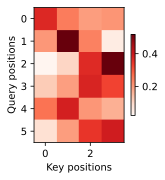

In [ ]:
# 加上一个包含序列结束词元
d2l.show_heatmaps(
    attention_weights[:, :, :, :len(engs[-1].split()) + 1].cpu(),
    xlabel='Key positions', ylabel='Query positions')

## 小结

* 在预测词元时，如果不是所有输入词元都是相关的，那么具有Bahdanau注意力的循环神经网络编码器-解码器会有选择地统计输入序列的不同部分。这是通过将上下文变量视为加性注意力池化的输出来实现的。
* 在循环神经网络编码器-解码器中，Bahdanau注意力将上一时间步的解码器隐状态视为查询，在所有时间步的编码器隐状态同时视为键和值。

## 练习

1. 在实验中用LSTM替换GRU。
1. 修改实验以将加性注意力打分函数替换为缩放点积注意力，它如何影响训练效率？


[Discussions](https://discuss.d2l.ai/t/5754)
